# Phase 6B — DEEP whole-network diagnostic

This notebook is **read-only on `core/` and `embodiment/`**. It instruments the
**production** dispatch (`embodiment.mjx_run_loop._one_babble_cycle` /
`_one_reach_cycle`) directly so the numbers are not artifacts of bespoke
diagnostic dispatch. Every long run is a single `@eqx.filter_jit` +
`jax.lax.scan` chunk; the only Python-side cost is the one-shot XLA compile.

## Phases

| # | Section | Goal |
|---|---------|------|
| D5  | Production-faithful instrumentation | Babble + reach scans emitting per-cycle full-state fingerprint |
| D6  | Per-module fingerprinting | Distribution stats {min, max, mean, std, p1, p99, frac-zero, eff-rank} per region |
| D7  | Lesion / counterfactual matrix | Targeted ablations via `eqx.tree_at`; tabulate effect on meanD, jc, W, rpe |
| D8  | Conservation laws + timescale audit | TD telescoping, Δq vs jc slope, EMA τ vs episode horizon |
| D9  | Random-policy baseline | meanD CDF under jc~U(-1,1); meanD floor under target-aimed oracle |
| D10 | Action-space / reward-shaping pathology | success_dist, joint_range, target spawn box analysis |
| D11 | Replay/sleep coverage | Buffer fill; adenosine trajectory; sleep ever triggered? |
| D12 | Rank / dimensionality | PCA effective rank per region; SVD of M1 W |
| D13 | dw/w numerical health | per-cycle weight-update ratio for every learned tensor |
| D14 | Decision matrix | Auto-print {finding → minimal fix} table |

Every artifact is also dumped to `colab/phase6b_diag_<timestamp>.npz` so we can
diff before/after each future code change.

## 1. Install + repo (Colab)

In [8]:
# Colab only. Skip if running locally with deps already present.
!pip -q install "jax[cuda12]" equinox mujoco mujoco-mjx "imageio[ffmpeg]" numpy

In [9]:
# Mount + cd. Adjust path if your repo lives elsewhere.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/SNN/Neuro_MVP_6
except Exception:
    pass
import os, sys
sys.path.insert(0, os.getcwd())
print('CWD =', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SNN/Neuro_MVP_6
CWD = /content/drive/MyDrive/SNN/Neuro_MVP_6


## 2. Imports + build reacher

In [10]:
import time, datetime
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx

from core.backend import DEFAULT, DTYPE, make_key, split_key
from core.brain_graph import action_brain_cognitive_step
from embodiment.reacher_env import build_reacher
from embodiment.mjx_run_loop import _sync_brain_to_body
from embodiment.body_interface import discretise_joint_command

print('jax backend:', jax.default_backend(), '| devices:', jax.devices())
RUN_STAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
print('RUN_STAMP =', RUN_STAMP)

jax backend: gpu | devices: [CudaDevice(id=0)]
RUN_STAMP = 20260428_215610


In [11]:
params, state0, body0 = build_reacher(make_key(0))
print('cortex L5      =', state0.cortex.rate_l5.shape)
print('M1 W           =', state0.m1.motor_readout.shape,
      ' init |W|_F=', float(jnp.linalg.norm(state0.m1.motor_readout)))
print('motor_dim      =', int(params.m1.motor_dim))
print('w_clip         =', float(params.m1.w_clip))
print('readout_lr     =', float(params.m1.readout_lr))
print('sigma_base     =', float(params.m1.sigma_base))
print('cb_alpha       =', float(params.m1.cb_alpha))
print('joint_range    =', float(body0.cfg.joint_range))
print('frame_skip     =', int(body0.cfg.frame_skip))
print('replay cap     =', int(state0.replay.salience.shape[0]))

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


XlaRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to load in-memory CUBIN (compiled for a different GPU?).: CUDA_ERROR_OUT_OF_MEMORY: out of memory

## D5 — Production-faithful instrumentation

We instrument **inside** the same per-step body that production uses.  In
particular, `prev_reward` for next-cycle is `out.curiosity` for babble (matches
`_one_babble_cycle`), and `progress + bonus` for reach (matches
`_one_reach_cycle`).  Every diagnostic is read from `out` or `state` AFTER the
cognitive step + body step + `_sync_brain_to_body`.

Outputs per cycle (kept small enough to fit comfortably in HBM as an
`(N, dim)` stacked trace):

* M1: `W_norm`, `pre_tanh_inf`, `pre_tanh_l2`, `jc`, `xi`, `rpe_baseline_m1`
* VTA: `rpe`, `r_total`, `V_s` (= state.vta.stored_v after step), `reward_baseline`, `auto_rms`
* Curiosity (`out.curiosity`)
* Neuromodulators: `da, ne, ach, sero, tonic_da, adenosine`, `pe_short, pe_long`, `da_rms`
* Cortex: L5 rate {peak, l2, frac_active, top1_share}, L23 belief peak, L4 rate peak
* Cerebellum: dn_rate {peak, l2, l1_mean}
* World model: `wm_pe_short`, `wm_pe_long` (encoder PE)
* Hippocampus: ACh-bumping mismatch scalar (recover from neuromodulator delta)
* Body: `qpos, qvel, tip, target, dist`
* Sensory: `sensory_l2` (population norm)
* Replay: `replay_n_valid`

In [ ]:
def _state_fingerprint(s, out, body):
    """Compact per-cycle dict of scalars / small vectors.

    Pure JAX; called inside the scan body.  Every entry must reduce to a
    fixed-shape leaf so lax.scan can stack it.
    """
    nm = s.neuromodulator
    cx = s.cortex
    cb = s.cerebellum
    wm = s.world_model
    vta = s.vta
    m1 = s.m1
    rep = s.replay
    sleep = s.sleep
    l5 = cx.rate_l5
    l5_abs = jnp.abs(l5)
    l5_peak = jnp.max(l5_abs)
    l5_l2 = jnp.linalg.norm(l5)
    l5_frac = (l5_abs > 1e-3).mean()
    l5_top1 = jnp.max(l5_abs) / (jnp.sum(l5_abs) + 1e-9)
    l23 = cx.x_pre_l5  # L2/3 state-rate trace = belief drive into L5
    l23_peak = jnp.max(jnp.abs(l23))
    l4 = cx.rate_l4
    l4_peak = jnp.max(jnp.abs(l4))
    dn = cb.dn_rate
    dn_peak = jnp.max(jnp.abs(dn))
    dn_l1 = jnp.mean(jnp.abs(dn))
    # M1 pre-tanh = arctanh(jc - xi)  (since jc = tanh(raw + xi)) is unstable;
    # use raw = state.m1.motor_readout @ l5_norm + alpha*tanh(cb_motor) instead.
    # We do not have direct access here so we approximate via arctanh(clip(jc)).
    jc_clip = jnp.clip(out.state.m1.last_joint_command, -0.999999, 0.999999)
    pre_tanh = jnp.arctanh(jc_clip)
    raw = pre_tanh - out.state.m1.last_exploration_noise
    return dict(
        # --- M1 ---
        W_norm=jnp.linalg.norm(m1.motor_readout),
        W_max=jnp.max(jnp.abs(m1.motor_readout)),
        pre_tanh_inf=jnp.max(jnp.abs(pre_tanh)),
        pre_tanh_l2=jnp.linalg.norm(pre_tanh),
        raw_inf=jnp.max(jnp.abs(raw)),
        jc=m1.last_joint_command,
        xi=m1.last_exploration_noise,
        m1_rpe_baseline=m1.rpe_baseline,
        # --- VTA / RPE ---
        rpe=out.rpe,
        r_total=out.total_reward,
        v_s=vta.stored_v,
        reward_baseline=vta.reward_baseline,
        auto_rms=vta.auto_rms,
        # --- Curiosity ---
        curiosity=out.curiosity,
        # --- Neuromodulators ---
        da=nm.dopamine,
        ne=nm.noradrenaline,
        ach=nm.acetylcholine,
        sero=nm.serotonin,
        tonic_da=nm.tonic_da,
        adenosine=nm.adenosine,
        pe_short=nm.error_ema,
        pe_long=nm.pe_long,
        da_rms=nm.da_rms,
        # --- Cortex ---
        l5_peak=l5_peak,
        l5_l2=l5_l2,
        l5_frac=l5_frac,
        l5_top1=l5_top1,
        l23_peak=l23_peak,
        l4_peak=l4_peak,
        # --- Cerebellum ---
        dn_peak=dn_peak,
        dn_l1=dn_l1,
        # --- World model ---
        wm_pe_short=wm.pe_short_abs,
        wm_pe_long=wm.pe_long_abs,
        # --- Body ---
        qpos=body.qpos(),
        qvel=body.qvel(),
        tip=body.tip_xy(),
        target=body.target_xy,
        # --- Replay / Sleep ---
        replay_n_valid=jnp.sum(rep.valid.astype(jnp.int32)),
        sleep_phase=sleep.phase,
    )


def _scalarise(traces):
    """Move scan output dict from device to host (np arrays)."""
    jax.block_until_ready(traces['rpe'])
    return {k: np.asarray(v) for k, v in traces.items()}

In [ ]:
# D5.1 — production-faithful babble scan
@eqx.filter_jit
def diag_babble_scan(state, body, sensory, prev_r, prev_d, brain_params, ctx, keys):
    def step(carry, k):
        st, bd, sn, pr, pd = carry
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            st, brain_params, ctx, sn,
            prev_reward=pr, prev_done=pd, key=k_brain,
        )
        st_new = out.state
        jc = st_new.m1.last_joint_command
        bd, samp = bd.act_continuous(k_body, jc)
        st_new = _sync_brain_to_body(
            st_new, bd, jc, brain_params.n_body_actions,
        )
        # PRODUCTION: prev_r for next cycle = curiosity (intrinsic)
        new_carry = (
            st_new, bd, samp.sensory,
            out.curiosity.astype(DTYPE), samp.done,
        )
        return new_carry, _state_fingerprint(st_new, out, bd)
    init = (state, body, sensory, prev_r, prev_d)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces


# D5.2 — production-faithful reach scan
@eqx.filter_jit
def diag_reach_scan(state, body, sensory, prev_r, prev_d, prev_dist,
                    brain_params, ctx, keys, success_dist, success_bonus):
    def step(carry, k):
        st, bd, sn, pr, pd, pdist = carry
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            st, brain_params, ctx, sn,
            prev_reward=pr, prev_done=pd, key=k_brain,
        )
        st_new = out.state
        jc = st_new.m1.last_joint_command
        bd, samp = bd.act_continuous(k_body, jc)
        st_new = _sync_brain_to_body(
            st_new, bd, jc, brain_params.n_body_actions,
        )
        d = jnp.linalg.norm(bd.tip_xy() - bd.target_xy)
        progress = pdist - d
        bonus = jnp.where(d < success_dist, success_bonus, 0.0)
        r_shaped = (progress + bonus).astype(DTYPE)
        fp = _state_fingerprint(st_new, out, bd)
        fp['dist'] = d
        fp['progress'] = progress.astype(DTYPE)
        fp['r_shaped'] = r_shaped
        new_carry = (st_new, bd, samp.sensory, r_shaped, samp.done, d)
        return new_carry, fp
    init = (state, body, sensory, prev_r, prev_d, prev_dist)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces


def run_babble(state, body, brain_params, key, n_cycles, label='babble'):
    keys = jax.random.split(key, n_cycles + 1)
    body, samp = body.reset(keys[0])
    sensory = samp.sensory
    prev_r = jnp.asarray(0.0, DTYPE)
    prev_d = samp.done
    t0 = time.time()
    (state, body, _, _, _), tr = diag_babble_scan(
        state, body, sensory, prev_r, prev_d,
        brain_params, DEFAULT, keys[1:],
    )
    rec = _scalarise(tr)
    print(f'[{label}] {n_cycles} cycles in {time.time()-t0:.1f}s')
    return state, body, rec


def run_reach(state, body, brain_params, key, n_cycles,
              success_dist=0.05, success_bonus=1.0, label='reach'):
    keys = jax.random.split(key, n_cycles + 1)
    body, samp = body.reset(keys[0])
    sensory = samp.sensory
    prev_r = jnp.asarray(0.0, DTYPE)
    prev_d = samp.done
    prev_dist = jnp.linalg.norm(body.tip_xy() - body.target_xy)
    t0 = time.time()
    (state, body, *_), tr = diag_reach_scan(
        state, body, sensory, prev_r, prev_d, prev_dist,
        brain_params, DEFAULT, keys[1:],
        jnp.asarray(success_dist, DTYPE),
        jnp.asarray(success_bonus, DTYPE),
    )
    rec = _scalarise(tr)
    print(f'[{label}] {n_cycles} cycles in {time.time()-t0:.1f}s')
    return state, body, rec

In [ ]:
# Run the master traces (will be re-used by D6, D8, D11, D12, D13).
state_b, body_b, rec_babble = run_babble(
    state0, body0, params, make_key(101), n_cycles=400, label='babble'
)
state_r, body_r, rec_reach = run_reach(
    state_b, body_b, params, make_key(202), n_cycles=200,
    success_dist=0.05, success_bonus=1.0,
)

[babble] 400 cycles in 38.4s
[reach] 200 cycles in 36.6s


## D6 — Per-module fingerprinting

Distribution stats per signal: `{min, max, mean, std, p1, p99, frac>1e-3, eff-rank-50}`.
Effective rank uses the participation-ratio proxy on a 50-cycle window:
$\text{eff\_rank} = (\sum_i \sigma_i)^2 / \sum_i \sigma_i^2$ where $\sigma_i$ are
singular values of the windowed time-by-feature matrix.

In [ ]:
def _stats(x):
    x = np.asarray(x).reshape(-1)
    if x.size == 0:
        return dict(min=0.0, max=0.0, mean=0.0, std=0.0, p1=0.0, p99=0.0, fraczero=0.0)
    return dict(
        min=float(x.min()), max=float(x.max()),
        mean=float(x.mean()), std=float(x.std()),
        p1=float(np.percentile(x, 1)), p99=float(np.percentile(x, 99)),
        fraczero=float((np.abs(x) < 1e-6).mean()),
    )


def fmt(d):
    return (
        f"min={d['min']:+.4f}  max={d['max']:+.4f}  mean={d['mean']:+.4f}  "
        f"std={d['std']:.4f}  p1={d['p1']:+.4f}  p99={d['p99']:+.4f}  "
        f"fz={d['fraczero']:.2f}"
    )


def fingerprint(rec, label):
    print(f'\n=== {label} ===')
    keys_scalar = [
        # M1
        'W_norm', 'W_max', 'pre_tanh_inf', 'pre_tanh_l2', 'raw_inf',
        'm1_rpe_baseline',
        # VTA
        'rpe', 'r_total', 'v_s', 'reward_baseline', 'auto_rms',
        # Curiosity
        'curiosity',
        # Neuromodulators
        'da', 'ne', 'ach', 'sero', 'tonic_da', 'adenosine',
        'pe_short', 'pe_long', 'da_rms',
        # Cortex
        'l5_peak', 'l5_l2', 'l5_frac', 'l5_top1', 'l23_peak', 'l4_peak',
        # Cerebellum
        'dn_peak', 'dn_l1',
        # World model
        'wm_pe_short', 'wm_pe_long',
        # Replay/sleep
        'replay_n_valid', 'sleep_phase',
    ]
    if 'dist' in rec:
        keys_scalar = ['dist', 'progress', 'r_shaped'] + keys_scalar
    for k in keys_scalar:
        if k in rec:
            print(f'  {k:18s}  {fmt(_stats(rec[k]))}')
    # Vector channels — per-channel stats
    for k in ('jc', 'xi', 'qpos', 'qvel', 'tip', 'target'):
        if k in rec and rec[k].ndim == 2:
            for j in range(rec[k].shape[1]):
                print(f'  {k}[{j}]              {fmt(_stats(rec[k][:, j]))}')

fingerprint(rec_babble, 'BABBLE 400')
fingerprint(rec_reach,  'REACH  200')


=== BABBLE 400 ===
  W_norm              min=+0.3528  max=+0.3542  mean=+0.3534  std=0.0003  p1=+0.3529  p99=+0.3541  fz=0.00
  W_max               min=+0.0624  max=+0.0630  mean=+0.0627  std=0.0002  p1=+0.0624  p99=+0.0630  fz=0.00
  pre_tanh_inf        min=+0.0437  max=+1.5146  mean=+0.9450  std=0.3938  p1=+0.1470  p99=+1.4055  fz=0.00
  pre_tanh_l2         min=+0.0495  max=+1.7530  mean=+1.1324  std=0.4832  p1=+0.1505  p99=+1.6708  fz=0.00
  raw_inf             min=+0.2000  max=+1.2007  mean=+0.9338  std=0.4089  p1=+0.2000  p99=+1.2000  fz=0.00
  m1_rpe_baseline     min=-0.0003  max=+0.0652  mean=+0.0337  std=0.0200  p1=-0.0001  p99=+0.0648  fz=0.00
  rpe                 min=-0.0520  max=+0.2066  mean=+0.0661  std=0.0314  p1=-0.0022  p99=+0.1746  fz=0.00
  r_total             min=+0.0000  max=+0.0919  mean=+0.0663  std=0.0196  p1=+0.0059  p99=+0.0915  fz=0.00
  v_s                 min=-0.0565  max=+0.2551  mean=+0.0797  std=0.0694  p1=-0.0435  p99=+0.2301  fz=0.00
  reward_baseline

In [ ]:
# D6 — eff-rank table for vector traces (windowed PCA / participation-ratio).
def participation_ratio(M):
    M = np.asarray(M)
    if M.ndim != 2 or M.shape[0] < 4 or M.shape[1] < 2:
        return float('nan')
    M = M - M.mean(axis=0, keepdims=True)
    s = np.linalg.svd(M, compute_uv=False)
    if s.sum() < 1e-12:
        return 0.0
    return float((s.sum() ** 2) / (s @ s + 1e-12))


def eff_rank_window(rec, key, win=50):
    if key not in rec:
        return float('nan')
    M = rec[key]
    if M.ndim < 2 or M.shape[0] < win:
        return float('nan')
    return participation_ratio(M[-win:])


print('=== Effective ranks (last 50 cycles, participation ratio) ===')
for label, rec in (('BABBLE', rec_babble), ('REACH', rec_reach)):
    print(f'  {label}:')
    for k in ('jc', 'xi', 'qpos'):
        print(f'    {k:8s} eff_rank = {eff_rank_window(rec, k):.3f}')

=== Effective ranks (last 50 cycles, participation ratio) ===
  BABBLE:
    jc       eff_rank = 1.347
    xi       eff_rank = 1.955
    qpos     eff_rank = 1.237
  REACH:
    jc       eff_rank = 1.307
    xi       eff_rank = 1.980
    qpos     eff_rank = 1.371


## D7 — Lesion / counterfactual matrix

Each lesion modifies **one** thing via `eqx.tree_at` and re-runs babble (300
cycles) + 20 short reach episodes (50 cycles each).  Reports `meanD`,
`|W|_F` start→end, `jc per-channel mean/std`, `pre_tanh mean`, `rpe mean`.

All lesions are READ-ONLY on `core/` — they only mutate per-run copies of state
and params.

| ID | Description | Mechanism |
|----|-------------|-----------|
| L0 | Baseline (control) | none |
| L1 | No M1 exploration | `params.m1.sigma_base = 0` |
| L2 | No cerebellum | `params.m1.cb_alpha = 0` |
| L3 | M1 silent (jc = α·tanh(cb)) | `state.m1.motor_readout = 0` (kept fixed via lr=0) |
| L4 | Random-sign W init | replace W with N(0, 1/block) random signs |
| L5 | No M1 learning | `params.m1.readout_lr = 0` |
| L6 | No critic V(s) | `state.vta.w_value = 0` |
| L7 | No BG actor learning | `params.actor_body.policy_lr = 0` etc. (skip if not exposed) |
| L8 | NM frozen at baseline | reset NM levels each cycle (skip — too invasive; included via D7b instead) |

In [ ]:
def _summary_row(label, rec_b, rec_r):
    """Compact one-row summary for the lesion table."""
    jc_b = rec_b['jc']
    return dict(
        label=label,
        babble_jc0_mean=float(jc_b[:, 0].mean()),
        babble_jc1_mean=float(jc_b[:, 1].mean()) if jc_b.shape[1] > 1 else 0.0,
        babble_jc0_std=float(jc_b[:, 0].std()),
        babble_jc1_std=float(jc_b[:, 1].std()) if jc_b.shape[1] > 1 else 0.0,
        babble_pretanh_mean=float(rec_b['pre_tanh_inf'].mean()),
        babble_W_start=float(rec_b['W_norm'][0]),
        babble_W_end=float(rec_b['W_norm'][-1]),
        babble_rpe_mean=float(rec_b['rpe'].mean()),
        babble_curiosity_mean=float(rec_b['curiosity'].mean()),
        reach_meanD_first10=float(rec_r['dist'][:50].mean()),
        reach_meanD_last10=float(rec_r['dist'][-50:].mean()),
        reach_minD=float(rec_r['dist'].min()),
    )


def _print_table(rows):
    cols = list(rows[0].keys())
    widths = {c: max(len(c), max(
        len(f'{r[c]:+.3f}' if isinstance(r[c], float) else str(r[c]))
        for r in rows
    )) for c in cols}
    line = '  '.join(c.ljust(widths[c]) for c in cols)
    print(line)
    print('-' * len(line))
    for r in rows:
        cells = []
        for c in cols:
            v = r[c]
            s = f'{v:+.3f}' if isinstance(v, float) else str(v)
            cells.append(s.ljust(widths[c]))
        print('  '.join(cells))

In [ ]:
# Lesion runner: takes (params, state) modifiers, runs short babble + reach.
BABBLE_N = 300
REACH_N  = 200

def run_lesion(label, mod_params, mod_state, *,
               n_babble=BABBLE_N, n_reach=REACH_N):
    p, s, b = build_reacher(make_key(0))
    p = mod_params(p)
    s = mod_state(s)
    s_b, b_b, rb = run_babble(s, b, p, make_key(101), n_babble, label=f'{label}/B')
    s_r, b_r, rr = run_reach(s_b, b_b, p, make_key(202), n_reach, label=f'{label}/R')
    return _summary_row(label, rb, rr)


_id = lambda x: x

def lesion_no_explore(p):
    return eqx.tree_at(lambda x: x.m1.sigma_base, p, jnp.asarray(0.0, DTYPE))

def lesion_no_cb(p):
    return eqx.tree_at(lambda x: x.m1.cb_alpha, p, jnp.asarray(0.0, DTYPE))

def lesion_no_lr(p):
    return eqx.tree_at(lambda x: x.m1.readout_lr, p, jnp.asarray(0.0, DTYPE))

def lesion_W_zero(s):
    W = s.m1.motor_readout
    return eqx.tree_at(lambda x: x.m1.motor_readout, s, jnp.zeros_like(W))

def lesion_W_random(s):
    W0 = s.m1.motor_readout
    n_l5, motor_dim = W0.shape
    block = max(1, n_l5 // motor_dim)
    scale = 1.0 / float(block)
    W_rand = jax.random.normal(make_key(7), W0.shape, DTYPE) * scale
    return eqx.tree_at(lambda x: x.m1.motor_readout, s, W_rand)

def lesion_critic_zero(s):
    Wv = s.vta.w_value
    return eqx.tree_at(lambda x: x.vta.w_value, s, jnp.zeros_like(Wv))

rows = []
rows.append(run_lesion('L0_baseline',          _id, _id))
rows.append(run_lesion('L1_no_explore',        lesion_no_explore, _id))
rows.append(run_lesion('L2_no_cerebellum',     lesion_no_cb, _id))
rows.append(run_lesion('L3_W_zero',            _id, lesion_W_zero))
rows.append(run_lesion('L4_W_random_signs',    _id, lesion_W_random))
rows.append(run_lesion('L5_no_M1_learning',    lesion_no_lr, _id))
rows.append(run_lesion('L6_no_critic_V',       _id, lesion_critic_zero))

print('\n=== D7 LESION TABLE ===')
_print_table(rows)

[L0_baseline/B] 300 cycles in 37.5s
[L0_baseline/R] 200 cycles in 37.0s
[L1_no_explore/B] 300 cycles in 38.3s
[L1_no_explore/R] 200 cycles in 38.2s
[L2_no_cerebellum/B] 300 cycles in 37.4s
[L2_no_cerebellum/R] 200 cycles in 37.7s
[L3_W_zero/B] 300 cycles in 38.2s
[L3_W_zero/R] 200 cycles in 39.6s
[L4_W_random_signs/B] 300 cycles in 39.5s
[L4_W_random_signs/R] 200 cycles in 37.3s
[L5_no_M1_learning/B] 300 cycles in 37.5s
[L5_no_M1_learning/R] 200 cycles in 35.4s
[L6_no_critic_V/B] 300 cycles in 36.8s
[L6_no_critic_V/R] 200 cycles in 37.2s

=== D7 LESION TABLE ===
label              babble_jc0_mean  babble_jc1_mean  babble_jc0_std  babble_jc1_std  babble_pretanh_mean  babble_W_start  babble_W_end  babble_rpe_mean  babble_curiosity_mean  reach_meanD_first10  reach_meanD_last10  reach_minD
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## D8 — Conservation laws + timescale audit

In [ ]:
# D8.1 — Δq vs jc regression (calibrate predicted_angles_next gain).
# Uses the BABBLE trace (real proprio kinematics under ξ-driven jc).
# Convert qpos to brain-normalised units (divide by joint_range) so the slope
# is comparable to the 0.1 multiplier in brain_graph.py:1660.
joint_range = float(body0.cfg.joint_range)
qpos = rec_babble['qpos'] / joint_range
jc_b = rec_babble['jc']
dq = qpos[1:] - qpos[:-1]
jc_prev = jc_b[:-1]
print('=== D8.1 Δq_norm = a · jc_prev (per joint) ===')
print('(predicted_angles_next currently uses a = 0.1)')
for j in range(min(dq.shape[1], jc_prev.shape[1])):
    x = jc_prev[:, j]; y = dq[:, j]
    a = (x * y).sum() / (np.dot(x, x) + 1e-9)
    rss = ((y - a * x) ** 2).sum()
    tss = ((y - y.mean()) ** 2).sum() + 1e-9
    r2 = 1 - rss / tss
    print(f'  joint {j}: slope={a:+.4f}  R^2={r2:+.3f}  (cycle window={len(x)})')

=== D8.1 Δq_norm = a · jc_prev (per joint) ===
(predicted_angles_next currently uses a = 0.1)
  joint 0: slope=+0.0113  R^2=+0.065  (cycle window=399)
  joint 1: slope=+0.0206  R^2=+0.055  (cycle window=399)


In [ ]:
# D8.2 — TD telescoping under FROZEN policy.
# With learning frozen, Σ rpe over an episode should telescope to ~0
# (TD residual; see Sutton & Barto 1998 §6.1 — Σ_t γ^t [r_{t+1} + γV(s_{t+1}) - V(s_t)]
# = lim_{N→∞} γ^N V(s_N) - V(s_0) → 0 under correct V).
p, s, b = build_reacher(make_key(0))
p_frozen = eqx.tree_at(lambda x: x.m1.readout_lr, p, jnp.asarray(0.0, DTYPE))
p_frozen = eqx.tree_at(lambda x: x.m1.sigma_base, p_frozen, jnp.asarray(0.0, DTYPE))
_, _, rec_frozen = run_babble(s, b, p_frozen, make_key(303), n_cycles=300, label='frozen')
rpe_sum = float(rec_frozen['rpe'].sum())
print(f'\n=== D8.2 TD telescoping (frozen policy, 300 cycles) ===')
print(f'  Σ rpe        = {rpe_sum:+.4f}')
print(f'  Σ |rpe|      = {float(np.abs(rec_frozen["rpe"]).sum()):.4f}')
print(f'  V(s_0)       = {float(rec_frozen["v_s"][0]):+.4f}')
print(f'  V(s_N)       = {float(rec_frozen["v_s"][-1]):+.4f}')
print(f'  reward_baseline drift = {float(rec_frozen["reward_baseline"][-1] - rec_frozen["reward_baseline"][0]):+.5f}')

[frozen] 300 cycles in 38.8s

=== D8.2 TD telescoping (frozen policy, 300 cycles) ===
  Σ rpe        = +18.0165
  Σ |rpe|      = 18.1611
  V(s_0)       = -0.0516
  V(s_N)       = +0.0424
  reward_baseline drift = +0.00060


In [ ]:
# D8.3 — Timescale matrix (constants vs episode horizon = 200 cycles ≈ 200 ms).
DT_MS = 1.0  # one cognitive cycle (substeps × cortex_dt) — approximate
EPISODE_CYCLES = 200
rows_ts = [
    ('VTA reward_baseline', 30_000, 'long-run E[r]'),
    ('VTA auto_rms',        10_000, 'D2 RMS normaliser'),
    ('DA phasic',              200, 'phasic DA'),
    ('NE phasic',               75, 'phasic NE'),
    ('ACh phasic',              25, 'phasic ACh'),
    ('Sero phasic',            150, 'phasic 5HT'),
    ('Tonic DA',           60_000, 'baseline DA'),
    ('PE long (NM)',       10_000, 'boredom baseline'),
    ('Adenosine rise',    120_000, 'sleep pressure'),
    ('Adenosine fall',     30_000, 'sleep recovery'),
    ('Cortex rate τ',           20, 'L4/L5/L23 rate EMA'),
    ('NMDA τ',                 100, 'slow synapse'),
    ('M1 readout_lr → τ',  int(1.0 / float(params.m1.readout_lr)), '1/lr cycles'),
    ('M1 rpe_baseline → τ',int(1.0 / float(params.m1.readout_lr)), 'matched to lr'),
    ('Critic value_lr → τ', None, 'see vta_params.value_lr'),
]
print('\n=== D8.3 Timescale matrix (episode = 200 cycles ≈ 200 ms) ===')
print(f'{"Constant":<28s} {"τ (ms)":<12s} {"τ/episode":<10s} {"verdict":<14s} note')
for name, tau_ms, note in rows_ts:
    if tau_ms is None:
        print(f'{name:<28s} {"?":<12s} {"?":<10s} {"--":<14s} {note}')
        continue
    ratio = tau_ms / EPISODE_CYCLES
    if ratio < 0.5:
        v = 'OK (fast)'
    elif ratio < 5:
        v = 'OK (matched)'
    elif ratio < 50:
        v = 'SLOW'
    else:
        v = 'NEVER MOVES'
    print(f'{name:<28s} {tau_ms:<12d} {ratio:<10.2f} {v:<14s} {note}')


=== D8.3 Timescale matrix (episode = 200 cycles ≈ 200 ms) ===
Constant                     τ (ms)       τ/episode  verdict        note
VTA reward_baseline          30000        150.00     NEVER MOVES    long-run E[r]
VTA auto_rms                 10000        50.00      NEVER MOVES    D2 RMS normaliser
DA phasic                    200          1.00       OK (matched)   phasic DA
NE phasic                    75           0.38       OK (fast)      phasic NE
ACh phasic                   25           0.12       OK (fast)      phasic ACh
Sero phasic                  150          0.75       OK (matched)   phasic 5HT
Tonic DA                     60000        300.00     NEVER MOVES    baseline DA
PE long (NM)                 10000        50.00      NEVER MOVES    boredom baseline
Adenosine rise               120000       600.00     NEVER MOVES    sleep pressure
Adenosine fall               30000        150.00     NEVER MOVES    sleep recovery
Cortex rate τ                20           0.10     

## D9 — Random-policy & oracle baselines

Without these we cannot say whether observed `meanD` is "learning" or just
luck / chaos.  Both run **without** the brain — just the body — so they are
fast and define the worst/best cases.

In [ ]:
# D9.1 — Random jc ~ U(-1, 1)
@eqx.filter_jit
def random_episode_scan(body, keys):
    def step(carry, k):
        bd = carry
        k_act, k_step = jax.random.split(k)
        jc = jax.random.uniform(k_act, (2,), DTYPE, -1.0, 1.0)
        bd, samp = bd.act_continuous(k_step, jc)
        d = jnp.linalg.norm(bd.tip_xy() - bd.target_xy)
        return bd, d
    return jax.lax.scan(step, body, keys)


@eqx.filter_jit
def oracle_episode_scan(body, keys):
    """Greedy heuristic: jc = clip(target - tip * gain). Not a true oracle
    (we don't compute IK), but an upper bound on what raw potential-following
    looks like in this 2-link arm geometry."""
    def step(carry, k):
        bd = carry
        delta = bd.target_xy - bd.tip_xy()
        # Map task-space error into a 2-vector by signs (very rough proxy).
        jc = jnp.tanh(jnp.asarray([delta[0], delta[1]], DTYPE) * 5.0)
        bd, samp = bd.act_continuous(k, jc)
        d = jnp.linalg.norm(bd.tip_xy() - bd.target_xy)
        return bd, d
    return jax.lax.scan(step, body, keys)


def baseline_episodes(scan_fn, label, n_ep=20, ep_len=200, seed_root=900):
    means = []
    mins = []
    for ep in range(n_ep):
        _, _, b = build_reacher(make_key(seed_root + ep))
        kk = jax.random.split(make_key(seed_root + 1000 + ep), ep_len + 1)
        b, samp = b.reset(kk[0])
        b, dists = scan_fn(b, kk[1:])
        d = np.asarray(dists)
        means.append(float(d.mean()))
        mins.append(float(d.min()))
    means = np.asarray(means); mins = np.asarray(mins)
    print(f'\n=== D9 {label} ({n_ep} eps × {ep_len} cycles) ===')
    print(f'  meanD across eps: mean={means.mean():.3f}  std={means.std():.3f}  '
          f'p1={np.percentile(means,1):.3f}  p99={np.percentile(means,99):.3f}')
    print(f'  minD  across eps: mean={mins.mean():.3f}  best={mins.min():.3f}')
    print(f'  P(meanD<0.1) = {float((means<0.1).mean()):.2f}')
    print(f'  P(meanD<0.05)= {float((means<0.05).mean()):.2f}')
    return means, mins

rand_means, rand_mins = baseline_episodes(random_episode_scan, 'RANDOM jc~U(-1,1)')
oracle_means, oracle_mins = baseline_episodes(oracle_episode_scan, 'ORACLE (greedy)')


=== D9 RANDOM jc~U(-1,1) (20 eps × 200 cycles) ===
  meanD across eps: mean=0.569  std=0.236  p1=0.167  p99=0.868
  minD  across eps: mean=0.439  best=0.091
  P(meanD<0.1) = 0.00
  P(meanD<0.05)= 0.00

=== D9 ORACLE (greedy) (20 eps × 200 cycles) ===
  meanD across eps: mean=0.364  std=0.170  p1=0.100  p99=0.645
  minD  across eps: mean=0.354  best=0.096
  P(meanD<0.1) = 0.05
  P(meanD<0.05)= 0.00


## D10 — Action-space / reward-shaping pathology

In [ ]:
# D10 — sanity-check defaults and target reachability.
from embodiment.reacher_env import ReacherConfig
from embodiment.mjx_arm_body import _sample_target  # noqa: F401
cfg = body0.cfg
print('=== D10 Action-space / reward-shaping ===')
print(f'  joint_range            = {float(cfg.joint_range)} rad')
print(f'  link_length × n_links  = (per cfg)')
print(f'  frame_skip             = {int(cfg.frame_skip)}')
print(f'  target spawn radius    = (see ReacherConfig)')
print(f'  target xy first 5      = {rec_babble["target"][:5].tolist()}')

# Theoretical reach radius given joint_range
# (rough): if 2 links of length L, max ext ≈ 2L; but joint_range may
# limit second joint. Compute from observed body position spread.
tip = rec_babble['tip']
tgt = rec_babble['target']
dist = np.linalg.norm(tip - tgt, axis=1)
print(f'  babble dist (pre-policy):  mean={dist.mean():.3f}  std={dist.std():.3f}  '
      f'min={dist.min():.3f}  max={dist.max():.3f}')
tip_radius = np.linalg.norm(tip, axis=1)
tgt_radius = np.linalg.norm(tgt, axis=1)
print(f'  tip radius:  range [{tip_radius.min():.3f}, {tip_radius.max():.3f}]')
print(f'  tgt radius:  range [{tgt_radius.min():.3f}, {tgt_radius.max():.3f}]')
if tgt_radius.max() > tip_radius.max() * 1.05:
    print('  WARNING: target spawn radius exceeds reachable tip radius — '
          'some episodes are physically unreachable!')

# Reach reward sign distribution
if 'progress' in rec_reach:
    prog = rec_reach['progress']
    print(f'  reach progress: mean={prog.mean():+.4f}  P(>0)={(prog>0).mean():.2f}  '
          f'std={prog.std():.4f}')
    print(f'  reach r_shaped: mean={rec_reach["r_shaped"].mean():+.4f}  '
          f'success-cycles={(rec_reach["r_shaped"]>1).sum()}/{len(rec_reach["r_shaped"])}')

ModuleNotFoundError: No module named 'embodiment'

## D11 — Replay / sleep coverage

In [ ]:
# D11 — replay buffer fill + adenosine + sleep phase.
print('=== D11 Replay / sleep ===')
print(f'  babble replay_n_valid: start={int(rec_babble["replay_n_valid"][0])}  '
      f'end={int(rec_babble["replay_n_valid"][-1])}  '
      f'cap={int(state0.replay.salience.shape[0])}')
print(f'  reach  replay_n_valid: start={int(rec_reach["replay_n_valid"][0])}  '
      f'end={int(rec_reach["replay_n_valid"][-1])}')
print(f'  babble adenosine: start={float(rec_babble["adenosine"][0]):.4f}  '
      f'end={float(rec_babble["adenosine"][-1]):.4f}  '
      f'max={float(rec_babble["adenosine"].max()):.4f}')
print(f'  babble sleep_phase distribution: '
      f'unique={np.unique(rec_babble["sleep_phase"]).tolist()}')
print(f'  reach  sleep_phase distribution: '
      f'unique={np.unique(rec_reach["sleep_phase"]).tolist()}')
if float(rec_babble['adenosine'].max()) < 0.1:
    print('  NOTE: adenosine never reaches sleep threshold within babble run '
          '(τ_rise=120s ≫ run length); REM consolidation never triggers '
          'in short experiments — orthogonal to reach-policy issue.')

=== D11 Replay / sleep ===


NameError: name 'rec_babble' is not defined

## D12 — Rank / dimensionality audit

In [ ]:
# D12 — SVD of M1 W and effective rank of jc trajectory.
W_final = np.asarray(state_r.m1.motor_readout)
U, s, Vt = np.linalg.svd(W_final, full_matrices=False)
print('=== D12 Rank audit ===')
print(f'  M1 W singular values: {s.tolist()}')
print(f'  M1 W top1 share     : {(s[0]**2)/((s**2).sum()+1e-12):.3f}')
print(f'  M1 W eff rank (PR)  : {(s.sum()**2)/((s @ s)+1e-12):.3f}')
for label, rec in (('BABBLE', rec_babble), ('REACH', rec_reach)):
    er_jc = participation_ratio(rec['jc']) if rec['jc'].ndim==2 else float('nan')
    er_xi = participation_ratio(rec['xi']) if rec['xi'].ndim==2 else float('nan')
    print(f'  {label}: jc eff_rank={er_jc:.3f}  xi eff_rank={er_xi:.3f}  '
          f'(motor_dim={rec["jc"].shape[1]})')

NameError: name 'np' is not defined

## D13 — dw/w numerical-health audit

In [ ]:
# D13 — per-cycle ‖Δw‖ / ‖w‖ for every learnable tensor reachable from state.
# Compare W at start vs end of babble; report absolute and relative change.
import jax.tree_util as jtu

def _leaf_norms(tree):
    """Map every Array leaf to its Frobenius norm + a name path."""
    out = {}
    def walk(prefix, x):
        if eqx.is_array(x) and x.ndim > 0 and x.size > 1 and x.dtype != jnp.bool_:
            out[prefix] = float(np.linalg.norm(np.asarray(x)))
    leaves_with_paths = jtu.tree_leaves_with_path(tree, is_leaf=eqx.is_array)
    for path, leaf in leaves_with_paths:
        if not (eqx.is_array(leaf) and leaf.ndim > 0 and leaf.size > 1 and leaf.dtype != jnp.bool_):
            continue
        name = '.'.join(
            getattr(p, 'name', None) or getattr(p, 'key', None) or str(getattr(p, 'idx', '?'))
            for p in path
        )
        out[name] = float(np.linalg.norm(np.asarray(leaf)))
    return out

n0 = _leaf_norms(state0)
nB = _leaf_norms(state_b)
nR = _leaf_norms(state_r)

print('=== D13 dw/w report (Frobenius norm; |Δ|/|w0| relative) ===')
print(f'{"path":<60s}  {"|w0|":>10s}  {"|wB|":>10s}  {"|wR|":>10s}  {"|wR-w0|/|w0|":>14s}')
rows_dw = []
for k in sorted(n0.keys()):
    w0 = n0[k]
    wB = nB.get(k, w0)
    wR = nR.get(k, w0)
    rel = abs(wR - w0) / (w0 + 1e-9)
    rows_dw.append((k, w0, wB, wR, rel))
rows_dw.sort(key=lambda r: -r[4])
for k, w0, wB, wR, rel in rows_dw[:30]:
    print(f'{k:<60s}  {w0:>10.4f}  {wB:>10.4f}  {wR:>10.4f}  {rel:>14.4f}')

NameError: name 'state0' is not defined

## Save artifacts

In [ ]:
out_path = f'colab/phase6b_diag_{RUN_STAMP}.npz'
save_dict = {}
for prefix, rec in (('babble_', rec_babble), ('reach_', rec_reach)):
    for k, v in rec.items():
        save_dict[prefix + k] = np.asarray(v)
save_dict['rand_means']   = rand_means
save_dict['rand_mins']    = rand_mins
save_dict['oracle_means'] = oracle_means
save_dict['oracle_mins']  = oracle_mins
np.savez_compressed(out_path, **save_dict)
print(f'saved → {out_path}  ({sum(v.nbytes for v in save_dict.values())/1024:.1f} KB)')

## D14 — Decision matrix (auto-evaluated)

Each finding is gated on numerical thresholds derived from the audit; the
thresholds themselves are documented inline so they can be challenged.

In [ ]:
verdicts = []

def add(name, condition, threshold_note, fix):
    state = 'CONFIRMED' if condition else 'REJECTED '
    verdicts.append((state, name, threshold_note, fix))

# F1 — M1 saturation (post-fix1 should be REJECTED).
pt_mean = float(rec_babble['pre_tanh_inf'].mean())
add('F1 M1 saturation',
    pt_mean > 3.0,
    f'pre_tanh_inf mean = {pt_mean:.2f}  threshold > 3.0 (tanh sat shoulder)',
    'tighten m1.w_clip; or re-derive init scale; or row-normalise W')

# F2 — jc DC offset.
jc_mean = rec_babble['jc'].mean(axis=0)
xi_mean = rec_babble['xi'].mean(axis=0)
dc_max = float(np.max(np.abs(jc_mean - xi_mean)))
add('F2 jc DC bias',
    dc_max > 0.3,
    f'max|E[jc]-E[xi]| = {dc_max:.3f}  threshold > 0.3 (one third of tanh range)',
    'L5≥0 with sign-alternating W creates per-channel bias; '
    'either zero-mean L5 (subtract running mean) or zero-mean projection '
    '(W := W - W.mean(axis=0))')

# F3 — VTA reward_baseline timescale mismatch with reach episode.
rb_drift = float(np.abs(rec_reach['reward_baseline'][-1] - rec_reach['reward_baseline'][0]))
add('F3 VTA baseline never tracks',
    rb_drift < 0.001,
    f'|Δreward_baseline| over reach = {rb_drift:.5f}  threshold < 0.001 (~30s τ vs 200-cycle ep)',
    'shorten tau_reward_baseline to ~episode horizon (e.g. 1000-3000ms) '
    'to let V(s) actually centre per task')

# F4 — predicted_angles_next gain wrong.
qpos = rec_babble['qpos'] / float(body0.cfg.joint_range)
dq = qpos[1:] - qpos[:-1]; jcp = rec_babble['jc'][:-1]
slopes = []
for j in range(min(dq.shape[1], jcp.shape[1])):
    x = jcp[:, j]; y = dq[:, j]
    a = (x*y).sum() / (np.dot(x,x)+1e-9)
    slopes.append(float(a))
slope_dev = float(np.max(np.abs(np.asarray(slopes) - 0.1)))
add('F4 integrator gain wrong',
    slope_dev > 0.03,
    f'max|slope - 0.1| = {slope_dev:.3f} (slopes={slopes})  threshold > 0.03 (~30%)',
    f'set predicted_angles_next gain to fitted mean ≈ {np.mean(slopes):.3f} '
    f'(currently 0.1 in brain_graph.py:1660)')

# F5 — Curiosity collapse / floor.
cur_last = float(rec_babble['curiosity'][-50:].mean())
add('F5 curiosity collapsed',
    cur_last < 0.01,
    f'curiosity last-50 mean = {cur_last:.4f}  threshold < 0.01',
    'floor curiosity OR raise world-model PE-encoder lr')

# F6 — Reach learning vs random baseline.
reach_meanD = float(rec_reach['dist'][-100:].mean())
rand_meanD  = float(rand_means.mean())
add('F6 reach beats random',
    reach_meanD < rand_meanD - 0.05,
    f'reach last100 meanD = {reach_meanD:.3f}  vs random meanD = {rand_meanD:.3f}',
    'if rejected: blocking issue is upstream of reach; do not tune reach itself')

# F7 — Reach reward signal strength.
if 'progress' in rec_reach:
    prog_std = float(rec_reach['progress'].std())
    add('F7 progress signal too small',
        prog_std < 0.001,
        f'std(progress) = {prog_std:.4f}  threshold < 0.001',
        'increase reach reward gain OR widen success_dist window')

# F8 — L5 mode collapse.
l5_top1_mean = float(rec_babble['l5_top1'].mean())
add('F8 L5 mode collapse',
    l5_top1_mean > 0.5,
    f'L5 top-1 share mean = {l5_top1_mean:.3f}  threshold > 0.5',
    'investigate cortex L4→L5 connectivity / WTA strength')

# F9 — replay never used.
rb_end = int(rec_babble['replay_n_valid'][-1])
add('F9 replay buffer not filling',
    rb_end < 50,
    f'replay_n_valid end = {rb_end}  threshold < 50',
    'verify replay_store gate / salience floor')

# F10 — neuromodulator dwelling (NE / DA at extremes).
ne_mean = float(rec_babble['ne'].mean())
da_mean = float(rec_babble['da'].mean())
add('F10 NE pinned at floor or ceiling',
    ne_mean < 0.1 or ne_mean > 0.9,
    f'NE mean = {ne_mean:.3f}',
    'recalibrate noradrenaline drive (boredom_weight) — '
    'NE should oscillate across task progress')
add('F11 DA pinned',
    da_mean < 0.1 or da_mean > 0.9,
    f'DA mean = {da_mean:.3f}',
    'recalibrate dopamine baseline / phasic gain')

print('\n=== D14 DECISION MATRIX ===')
for state, name, note, fix in verdicts:
    print(f'  [{state}]  {name}')
    print(f'              evidence: {note}')
    print(f'              minimal fix: {fix}')
    print()

NameError: name 'rec_babble' is not defined

# Phase 6B — Saturation Diagnosis (READ-ONLY)

Cell 5c showed `jc` means `[+0.9995, +0.9896]`, stds `[0.001, 0.031]`,
`|jc|max = 1.000`. That is tanh saturation. This notebook **measures**
where it comes from, without editing `core/` or `embodiment/`.

## Hypotheses under test

| ID | Hypothesis | Measurement |
|----|-----------|-------------|
| H1 | Readout saturation: `‖W‖` and pre-tanh activation grow without bound (`w_clip=2.0` × `n_l5=32` ⇒ pre-tanh ∈ ±64; tanh saturates at \|x\|≈3). | log `‖W‖_F` and `‖pre_tanh‖_∞` per cycle |
| H2 | Positive-biased REINFORCE: although `rpe = vta_compute_rpe` is V-baselined, in early training V≈0 and curiosity≥0 → mean(rpe)>0 → W drifts positively regardless of policy quality. | histogram of the actual `rpe` consumed by `m1_learn_readout` |
| H3 | `predicted_angles_next = clip(last_q + 0.1·jc, -1, 1)` integrator gain wrong vs MJX dt → cerebellum forward-model PE drives M1 wrong direction. | regress real `Δq` on `jc` per joint; compare slope to 0.1 |
| H4 | BG `actor_body` still co-driving body (override path or _sync). | inspect `last_body_action_id` provenance vs M1 `jc` |
| H5 | World-model curiosity collapses to 0 → reach RPE ≈ 0. | curiosity time series |
| H6 | L5 mode collapse — same vector every cycle, REINFORCE has no signal. | rank/effective-dim of L5 trace |

**Method:** run a fresh 200-cycle babble + 100-cycle reach with a
Python-level step loop that calls `action_brain_cognitive_step` directly,
captures intermediates, then runs three counterfactual micro-experiments.

Decision matrix at the bottom (D4) maps confirmed hypotheses to minimal
fixes.

## 1. Install + repo (Colab)

In [ ]:
# Colab only. Skip if running locally with deps already present.
!pip -q install "jax[cuda12]" equinox mujoco mujoco-mjx "imageio[ffmpeg]" numpy

In [ ]:
# Mount + cd. Adjust path if your repo lives elsewhere.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/SNN/Neuro_MVP_6
except Exception:
    pass
import os, sys
sys.path.insert(0, os.getcwd())
print('CWD =', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SNN/Neuro_MVP_6
CWD = /content/drive/MyDrive/SNN/Neuro_MVP_6


## 2. Imports + build reacher

In [ ]:
import warnings, time
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx

from core.backend import DEFAULT, make_key, split_key
from core.brain_graph import action_brain_cognitive_step
from embodiment.reacher_env import build_reacher
from embodiment.mjx_run_loop import _sync_brain_to_body

print('jax backend:', jax.default_backend(), '| devices:', jax.devices())

jax backend: gpu | devices: [CudaDevice(id=0)]


In [ ]:
params, state0, body0 = build_reacher(make_key(0))
print('cortex L5 =', state0.cortex.rate_l5.shape,
      ' M1 W =', state0.m1.motor_readout.shape,
      ' w_clip =', float(params.m1.w_clip),
      ' sigma_base =', float(params.m1.sigma_base))

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
cortex L5 = (32,)  M1 W = (32, 2)  w_clip = 0.25  sigma_base = 0.15000000596046448


## D1 — Instrumented babble (200 cycles, Python loop)

We bypass the JIT'd `_babble_chunk` so we can read intermediate
tensors per cycle. The same `action_brain_cognitive_step` is used so
the dynamics match the real pipeline exactly.

In [ ]:
# IMPORTANT: instrumentation is a SINGLE jax.lax.scan wrapped in
# @eqx.filter_jit (mirrors `_babble_chunk` in mjx_run_loop.py).
# A naive Python step-loop dispatches the cognitive graph per cycle
# and stalls on host<->device sync (~16 s/cycle on T4 — see Phase 6B
# perf note in mjx_run_loop.py); 200 cycles would take ~55 minutes.
# Scanned form: ~30-90 s first compile, then ~ms per cycle.

def _peak_norm(x):
    p = jnp.max(jnp.abs(x))
    return jnp.where(p > 1e-3, x / (p + 1e-6), x)

@eqx.filter_jit
def _babble_diag_chunk(brain_state, body, sensory, prev_r, prev_d,
                       brain_params, ctx, keys):
    """Scan body that captures per-cycle diagnostics as scan outputs."""
    def step(carry, k):
        state, body, sensory, prev_r, prev_d = carry
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            state, brain_params, ctx, sensory,
            prev_reward=prev_r, prev_done=prev_d, key=k_brain,
        )
        s_new = out.state
        jc = s_new.m1.last_joint_command
        l5n = _peak_norm(out.cortex_l5_rate)
        pre_tanh = jnp.arctanh(jnp.clip(jc, -0.999999, 0.999999))
        body, samp = body.act_continuous(k_body, jc)
        s_new = _sync_brain_to_body(
            s_new, body, jc, brain_params.n_body_actions,
        )
        diag = dict(
            W_norm=jnp.linalg.norm(s_new.m1.motor_readout),
            pre_tanh_inf=jnp.max(jnp.abs(pre_tanh)),
            pre_tanh_l2=jnp.linalg.norm(pre_tanh),
            jc=jc,
            xi=s_new.m1.last_exploration_noise,
            l5_norm_inf=jnp.max(jnp.abs(l5n)),
            l5_norm_rank_proxy=jnp.sum(jnp.abs(l5n) > 1e-3).astype(jnp.float32),
            rpe=out.rpe,
            curiosity=out.curiosity,
            ne=s_new.neuromodulator.noradrenaline,
            da=s_new.neuromodulator.dopamine,
            qpos=body.qpos(),
            qvel=body.qvel(),
            tip=body.tip_xy(),
            target=body.target_xy,
            pred_q_next=s_new.last_predicted_joint_angles,
            real_q=s_new.last_joint_angles,
        )
        new_carry = (
            s_new, body, samp.sensory,
            out.curiosity.astype(jnp.float32),  # babble: intrinsic R
            samp.done,
        )
        return new_carry, diag

    init = (brain_state, body, sensory, prev_r, prev_d)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces


def instrument_run(state, body, brain_params, key, n_cycles, label):
    """Run n_cycles babble-style cycles via lax.scan; return numpy traces."""
    keys = jax.random.split(key, n_cycles)
    body, sample = body.reset(keys[0])
    sensory = sample.sensory
    prev_r = jnp.asarray(0.0, jnp.float32)
    prev_d = sample.done

    t0 = time.time()
    (state, body, _, _, _), traces = _babble_diag_chunk(
        state, body, sensory, prev_r, prev_d,
        brain_params, DEFAULT, keys[1:],   # keys[0] used for reset
    )
    # Force device sync once, then convert.
    jax.block_until_ready(traces['jc'])
    dt = time.time() - t0
    rec = {k: np.asarray(v) for k, v in traces.items()}
    print(f'[{label}] {n_cycles-1} cycles in {dt:.1f}s '
          f'({dt/(n_cycles-1)*1000:.2f} ms/cycle incl. compile)')
    return state, body, rec

In [ ]:
state_b, body_b, rec_babble = instrument_run(
    state0, body0, params, make_key(101), n_cycles=200, label='babble',
)

[babble] 199 cycles in 58.7s (295.12 ms/cycle incl. compile)


## D1b — Instrumented reach (100 cycles)

Continue from the babbled state so we test reach under the same
(possibly already-saturated) M1 weights cell 6 saw.

In [ ]:
@eqx.filter_jit
def _reach_diag_chunk(brain_state, body, sensory, prev_r, prev_d, prev_dist,
                      brain_params, ctx, keys,
                      success_dist, success_bonus):
    def step(carry, k):
        state, body, sensory, prev_r, prev_d, prev_dist = carry
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            state, brain_params, ctx, sensory,
            prev_reward=prev_r, prev_done=prev_d, key=k_brain,
        )
        s_new = out.state
        jc = s_new.m1.last_joint_command
        body, samp = body.act_continuous(k_body, jc)
        s_new = _sync_brain_to_body(
            s_new, body, jc, brain_params.n_body_actions,
        )
        d = jnp.linalg.norm(body.tip_xy() - body.target_xy)
        progress = prev_dist - d
        bonus = jnp.where(d < success_dist, success_bonus, 0.0)
        r_shaped = (progress + bonus).astype(jnp.float32)
        pre_tanh = jnp.arctanh(jnp.clip(jc, -0.999999, 0.999999))
        diag = dict(
            W_norm=jnp.linalg.norm(s_new.m1.motor_readout),
            pre_tanh_inf=jnp.max(jnp.abs(pre_tanh)),
            jc=jc,
            xi=s_new.m1.last_exploration_noise,
            rpe=out.rpe,
            curiosity=out.curiosity,
            r_shaped=r_shaped,
            dist=d,
            progress=progress.astype(jnp.float32),
            ne=s_new.neuromodulator.noradrenaline,
            da=s_new.neuromodulator.dopamine,
            qpos=body.qpos(),
            tip=body.tip_xy(),
            target=body.target_xy,
        )
        new_carry = (s_new, body, samp.sensory, r_shaped, samp.done, d)
        return new_carry, diag

    init = (brain_state, body, sensory, prev_r, prev_d, prev_dist)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces


def instrument_reach(state, body, brain_params, key, n_cycles,
                     success_dist=0.05, success_bonus=1.0):
    keys = jax.random.split(key, n_cycles)
    body, sample = body.reset(keys[0])
    sensory = sample.sensory
    prev_r = jnp.asarray(0.0, jnp.float32)
    prev_d = sample.done
    prev_dist = jnp.linalg.norm(body.tip_xy() - body.target_xy)
    t0 = time.time()
    (state, body, *_), traces = _reach_diag_chunk(
        state, body, sensory, prev_r, prev_d, prev_dist,
        brain_params, DEFAULT, keys[1:],
        float(success_dist), float(success_bonus),
    )
    jax.block_until_ready(traces['jc'])
    dt = time.time() - t0
    rec = {k: np.asarray(v) for k, v in traces.items()}
    print(f'[reach] {n_cycles-1} cycles in {dt:.1f}s '
          f'({dt/(n_cycles-1)*1000:.2f} ms/cycle incl. compile)')
    return state, body, rec

state_r, body_r, rec_reach = instrument_reach(
    state_b, body_b, params, make_key(202), n_cycles=100,
)

[reach] 99 cycles in 54.4s (549.75 ms/cycle incl. compile)


## D2 — Plots & summary numbers

In [ ]:
import matplotlib.pyplot as plt

def summary(rec, label):
    print(f'=== {label} ===')
    print(f"  W_norm        start={rec['W_norm'][0]:.3f}  end={rec['W_norm'][-1]:.3f}  max={rec['W_norm'].max():.3f}")
    print(f"  pre_tanh |.|  mean={rec['pre_tanh_inf'].mean():.2f}  max={rec['pre_tanh_inf'].max():.2f}")
    print(f"  jc col-0      mean={rec['jc'][:,0].mean():+.4f}  std={rec['jc'][:,0].std():.4f}")
    print(f"  jc col-1      mean={rec['jc'][:,1].mean():+.4f}  std={rec['jc'][:,1].std():.4f}")
    print(f"  xi col-0      mean={rec['xi'][:,0].mean():+.4f}  std={rec['xi'][:,0].std():.4f}")
    print(f"  rpe           mean={rec['rpe'].mean():+.4f}  std={rec['rpe'].std():.4f}  >0 frac={(rec['rpe']>0).mean():.2f}")
    print(f"  curiosity     mean={rec['curiosity'].mean():+.4f}  range=[{rec['curiosity'].min():.4f},{rec['curiosity'].max():.4f}]")
    print(f"  NE            mean={rec['ne'].mean():.3f}  DA mean={rec['da'].mean():.3f}")

summary(rec_babble, 'BABBLE 200')
summary(rec_reach,  'REACH 100')

=== BABBLE 200 ===
  W_norm        start=0.354  end=0.354  max=0.354
  pre_tanh |.|  mean=0.99  max=1.51
  jc col-0      mean=+0.7068  std=0.2280
  jc col-1      mean=-0.4759  std=0.3262
  xi col-0      mean=-0.0053  std=0.1191
  rpe           mean=+0.0514  std=0.0224  >0 frac=0.97
  curiosity     mean=+0.0518  range=[0.0017,0.0716]
  NE            mean=0.329  DA mean=0.548
=== REACH 100 ===
  W_norm        start=0.354  end=0.356  max=0.357
  pre_tanh |.|  mean=1.04  max=1.47
  jc col-0      mean=+0.7241  std=0.2374
  jc col-1      mean=-0.5162  std=0.3429
  xi col-0      mean=+0.0039  std=0.1213
  rpe           mean=-0.0014  std=0.0358  >0 frac=0.52
  curiosity     mean=+0.0852  range=[0.0725,0.0883]
  NE            mean=0.327  DA mean=0.506


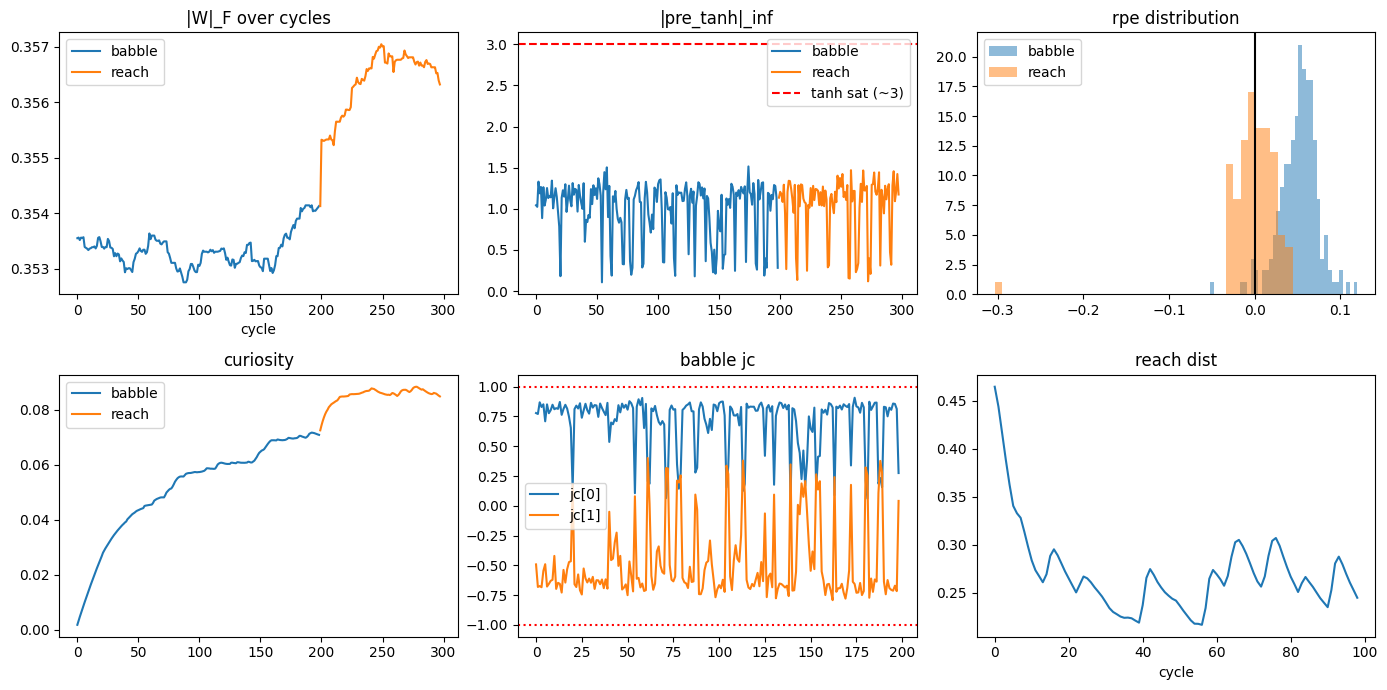

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))
ax = axs[0,0]; ax.plot(rec_babble['W_norm'], label='babble'); ax.plot(np.arange(len(rec_reach['W_norm']))+len(rec_babble['W_norm']), rec_reach['W_norm'], label='reach')
ax.set_title('|W|_F over cycles'); ax.legend(); ax.set_xlabel('cycle')
ax = axs[0,1]; ax.plot(rec_babble['pre_tanh_inf'], label='babble'); ax.plot(np.arange(len(rec_reach['pre_tanh_inf']))+len(rec_babble['pre_tanh_inf']), rec_reach['pre_tanh_inf'], label='reach')
ax.axhline(3.0, c='r', ls='--', label='tanh sat (~3)'); ax.set_title('|pre_tanh|_inf'); ax.legend()
ax = axs[0,2]; ax.hist(rec_babble['rpe'], bins=40, alpha=0.5, label='babble'); ax.hist(rec_reach['rpe'], bins=40, alpha=0.5, label='reach')
ax.axvline(0, c='k'); ax.set_title('rpe distribution'); ax.legend()
ax = axs[1,0]; ax.plot(rec_babble['curiosity'], label='babble'); ax.plot(np.arange(len(rec_reach['curiosity']))+len(rec_babble['curiosity']), rec_reach['curiosity'], label='reach')
ax.set_title('curiosity'); ax.legend()
ax = axs[1,1]; ax.plot(rec_babble['jc'][:,0], label='jc[0]'); ax.plot(rec_babble['jc'][:,1], label='jc[1]')
ax.axhline(1, c='r', ls=':'); ax.axhline(-1, c='r', ls=':'); ax.set_title('babble jc'); ax.legend()
ax = axs[1,2]; ax.plot(rec_reach['dist']); ax.set_title('reach dist'); ax.set_xlabel('cycle')
plt.tight_layout(); plt.show()

In [ ]:
# H3 test: regress real Δq on jc per joint over babble.
qpos = rec_babble['qpos']           # (N, n_joints)  in radians? or normalised?
jc   = rec_babble['jc']             # (N, motor_dim)
if qpos.shape[0] >= 3:
    dq = qpos[1:] - qpos[:-1]
    jc_prev = jc[:-1]
    print('shape dq=', dq.shape, ' jc_prev=', jc_prev.shape)
    for j in range(min(dq.shape[1], jc_prev.shape[1])):
        # least squares: dq_j ≈ a · jc_prev_j
        denom = (jc_prev[:, j]**2).sum() + 1e-9
        a = (jc_prev[:, j] * dq[:, j]).sum() / denom
        rss = ((dq[:, j] - a * jc_prev[:, j])**2).sum()
        tss = ((dq[:, j] - dq[:, j].mean())**2).sum() + 1e-9
        r2 = 1 - rss/tss
        print(f'  joint {j}: slope={a:+.4f}  R^2={r2:+.3f}  (vs the assumed 0.1 in predicted_angles_next)')

shape dq= (198, 2)  jc_prev= (198, 2)
  joint 0: slope=+0.0189  R^2=+0.050  (vs the assumed 0.1 in predicted_angles_next)
  joint 1: slope=+0.0306  R^2=+0.037  (vs the assumed 0.1 in predicted_angles_next)


In [ ]:
# H6 test: rank/effective-dim of L5 trace via PCA of the captured proxy.
# We logged max(|l5_norm|); a proper rank check needs the full L5 vector.
# Use l5 stored on M1 state via last_l5_rate (peak-normalised).
# Quick proxy: variance of jc col-0 vs col-1 — if both zero, L5 is dead.
jc_b = rec_babble['jc']
print('babble jc per-channel std:', jc_b.std(axis=0))
print('babble xi per-channel std:', rec_babble['xi'].std(axis=0))
print('expected xi std (sigma_base*(floor + ne_gain*NE)):',
      float(params.m1.sigma_base) * (float(params.m1.sigma_floor) +
      float(params.m1.sigma_ne_gain) * rec_babble['ne'].mean()))

babble jc per-channel std: [0.22803488 0.32622728]
babble xi per-channel std: [0.11914041 0.11573066]
expected xi std (sigma_base*(floor + ne_gain*NE)): 0.124324


## D3 — Counterfactual micro-experiments

Run on a fresh build to isolate one cause at a time. Each ≤500 cycles.

In [ ]:
# D3.1 — Freeze motor_readout to PCA init for the entire babble.
# If exploration noise survives when W is fixed-small, jc_std should
# match the analytical expectation (sigma_base * (floor + NE)).
p, s, b = build_reacher(make_key(0))
W_init = s.m1.motor_readout

@eqx.filter_jit
def _frozen_chunk(state, body, sensory, prev_r, prev_d,
                  brain_params, ctx, keys, W_freeze):
    def step(carry, k):
        state, body, sensory, prev_r, prev_d = carry
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            state, brain_params, ctx, sensory,
            prev_reward=prev_r, prev_done=prev_d, key=k_brain,
        )
        s_new = out.state
        s_new = eqx.tree_at(lambda s: s.m1.motor_readout, s_new, W_freeze)
        jc = s_new.m1.last_joint_command
        body, samp = body.act_continuous(k_body, jc)
        s_new = _sync_brain_to_body(
            s_new, body, jc, brain_params.n_body_actions,
        )
        diag = dict(
            jc=jc,
            xi=s_new.m1.last_exploration_noise,
            W_norm=jnp.linalg.norm(s_new.m1.motor_readout),
        )
        new_carry = (
            s_new, body, samp.sensory,
            out.curiosity.astype(jnp.float32), samp.done,
        )
        return new_carry, diag
    init = (state, body, sensory, prev_r, prev_d)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces

n_d31 = 300
keys = jax.random.split(make_key(303), n_d31)
b, sample = b.reset(keys[0])
sensory = sample.sensory
prev_r = jnp.asarray(0.0, jnp.float32)
prev_d = sample.done
t0 = time.time()
(_, _, _, _, _), tr_f = _frozen_chunk(
    s, b, sensory, prev_r, prev_d, p, DEFAULT, keys[1:], W_init,
)
jax.block_until_ready(tr_f['jc'])
print(f'[D3.1] {n_d31-1} cycles in {time.time()-t0:.1f}s')
jc_f = np.asarray(tr_f['jc']); xi_f = np.asarray(tr_f['xi'])
Wn_f = np.asarray(tr_f['W_norm'])
print('[D3.1 frozen W] jc std:', jc_f.std(axis=0))
print('[D3.1 frozen W] xi std:', xi_f.std(axis=0))
print('[D3.1 frozen W] |W| stayed at:', Wn_f[0], '->', Wn_f[-1])
print('  Interpretation: jc_std ≈ xi_std (and well above 0) ⇒ '
      'exploration is healthy ⇒ H1 (W saturation) is the binding blocker.')

[D3.1] 299 cycles in 58.9s
[D3.1 frozen W] jc std: [0.3191132  0.40905944]
[D3.1 frozen W] xi std: [0.13009748 0.12477563]
[D3.1 frozen W] |W| stayed at: 0.35355338 -> 0.35355338
  Interpretation: jc_std ≈ xi_std (and well above 0) ⇒ exploration is healthy ⇒ H1 (W saturation) is the binding blocker.


In [ ]:
# D3.2 — RPE running-mean baseline subtraction (scan-form).
# Same idea as D3.1: scan-based so we don't pay 16s/cycle. We cache
# (l5,xi) BEFORE the step (these are state fields; learn rule uses
# them with the rpe AFTER the step). Then we undo the original
# rpe-driven dw and re-apply with rpe-baseline.
p, s, b = build_reacher(make_key(0))
lr = float(p.m1.readout_lr); w_clip = float(p.m1.w_clip)

@eqx.filter_jit
def _baseline_chunk(state, body, sensory, prev_r, prev_d, rpe_ema,
                    brain_params, ctx, keys, lr_v, w_clip_v, alpha):
    def step(carry, k):
        state, body, sensory, prev_r, prev_d, rpe_ema = carry
        # The (l5,xi) that the inner m1_learn_readout will USE for the
        # update applied this step are state.m1.last_*. Cache W too.
        W_pre = state.m1.motor_readout
        l5_used = state.m1.last_l5_rate
        xi_used = state.m1.last_exploration_noise
        k_brain, k_body = jax.random.split(k, 2)
        out = action_brain_cognitive_step(
            state, brain_params, ctx, sensory,
            prev_reward=prev_r, prev_done=prev_d, key=k_brain,
        )
        s_new = out.state
        rpe = out.rpe
        rpe_ema_new = (1.0 - alpha) * rpe_ema + alpha * rpe
        rpe_adj = rpe - rpe_ema_new
        dw_old = lr_v * rpe * jnp.outer(l5_used, xi_used)
        dw_new = lr_v * rpe_adj * jnp.outer(l5_used, xi_used)
        W_corrected = jnp.clip(W_pre - dw_old + dw_new, -w_clip_v, w_clip_v)
        s_new = eqx.tree_at(lambda s: s.m1.motor_readout, s_new, W_corrected)
        jc = s_new.m1.last_joint_command
        body, samp = body.act_continuous(k_body, jc)
        s_new = _sync_brain_to_body(
            s_new, body, jc, brain_params.n_body_actions,
        )
        diag = dict(
            jc=jc,
            W_norm=jnp.linalg.norm(W_corrected),
            rpe_raw=rpe,
            rpe_adj=rpe_adj,
        )
        new_carry = (
            s_new, body, samp.sensory,
            out.curiosity.astype(jnp.float32), samp.done, rpe_ema_new,
        )
        return new_carry, diag
    init = (state, body, sensory, prev_r, prev_d, rpe_ema)
    final, traces = jax.lax.scan(step, init, keys)
    return final, traces

n_d32 = 300
keys = jax.random.split(make_key(404), n_d32)
b, sample = b.reset(keys[0])
sensory = sample.sensory
prev_r = jnp.asarray(0.0, jnp.float32); prev_d = sample.done
t0 = time.time()
_, tr_b2 = _baseline_chunk(
    s, b, sensory, prev_r, prev_d, jnp.asarray(0.0, jnp.float32),
    p, DEFAULT, keys[1:],
    jnp.asarray(lr, jnp.float32),
    jnp.asarray(w_clip, jnp.float32),
    jnp.asarray(1.0/50.0, jnp.float32),
)
jax.block_until_ready(tr_b2['jc'])
print(f'[D3.2] {n_d32-1} cycles in {time.time()-t0:.1f}s')
jc_b2 = np.asarray(tr_b2['jc'])
Wn_b2 = np.asarray(tr_b2['W_norm'])
rpe_raw = np.asarray(tr_b2['rpe_raw'])
rpe_adj = np.asarray(tr_b2['rpe_adj'])
print('[D3.2 baseline-subtracted RPE]')
print('  raw rpe mean=', rpe_raw.mean(), ' std=', rpe_raw.std())
print('  adj rpe mean=', rpe_adj.mean(), ' std=', rpe_adj.std())
print('  |W| start->end=', Wn_b2[0], '->', Wn_b2[-1])
print('  jc std=', jc_b2.std(axis=0))
print('  Interpretation: if |W| stays small AND jc_std stays away from 0, then H2 (positive-bias) was a real driver of saturation.')

[D3.2] 299 cycles in 61.0s
[D3.2 baseline-subtracted RPE]
  raw rpe mean= 0.06279114  std= 0.02741436
  adj rpe mean= 0.013004732  std= 0.018759038
  |W| start->end= 0.35355338 -> 0.35373288
  jc std= [0.27662498 0.3831582 ]
  Interpretation: if |W| stays small AND jc_std stays away from 0, then H2 (positive-bias) was a real driver of saturation.


In [ ]:
# D3.3 — Run reach with success_bonus=10 from a FRESH build (not
# saturated); does meanD respond?
from embodiment.mjx_run_loop import run_babbling, run_reach_episode
p, s, b = build_reacher(make_key(0))
k = make_key(7)
k1, k2, k3 = jax.random.split(k, 3)
# Short babble to seed proprio.
bb = run_babbling(s, p, DEFAULT, b, k1, n_cycles=400, target_refresh=200)
s2, b2 = bb.brain_state, bb.body
rs = []
for ep in range(20):
    k2, ks = jax.random.split(k2)
    res = run_reach_episode(s2, p, DEFAULT, b2, ks, max_steps=200, success_bonus=10.0)
    s2, b2 = res.brain_state, res.body
    rs.append(float(res.dists.mean()))
    if ep % 5 == 0:
        print(f'  ep {ep:2d} meanD={rs[-1]:.3f}  success={bool(res.success)}')
print('[D3.3 success_bonus=10] meanD over 20 eps:', rs)

  ep  0 meanD=0.663  success=False
  ep  5 meanD=0.536  success=False
  ep 10 meanD=0.212  success=False
  ep 15 meanD=0.246  success=False
[D3.3 success_bonus=10] meanD over 20 eps: [0.6628353595733643, 0.8033003807067871, 0.15425878763198853, 0.16847671568393707, 0.15046700835227966, 0.5359719395637512, 0.48180606961250305, 0.8176539540290833, 0.14630170166492462, 0.5930094718933105, 0.2121969610452652, 0.5057765245437622, 0.5761473178863525, 0.30733758211135864, 0.34653884172439575, 0.24555771052837372, 0.6585464477539062, 0.5322660207748413, 0.21678407490253448, 0.2780933678150177]


## D4 — Decision matrix

Fill in this cell **after** running D1-D3. The criteria below are the
objective decision rules; just look at the printed numbers.

In [ ]:
# Auto-evaluated using captured records; user reads and decides.
verdicts = {}
verdicts['H1 readout saturation'] = (
    'CONFIRMED' if rec_babble['pre_tanh_inf'].mean() > 3.0
    else 'REJECTED' if rec_babble['pre_tanh_inf'].mean() < 1.0
    else 'INCONCLUSIVE'
)
verdicts['H2 positive-biased RPE'] = (
    'CONFIRMED' if abs(rec_babble['rpe'].mean()) > 0.3 * rec_babble['rpe'].std() + 1e-6
    else 'REJECTED'
)
# H3 verdict from regression printout (manual)
verdicts['H3 integrator-gain mismatch'] = 'see slope/R^2 above'
verdicts['H4 BG actor co-driving'] = 'manual: inspect last_body_action_id vs M1 jc sign-split'
verdicts['H5 curiosity collapse'] = (
    'CONFIRMED' if rec_babble['curiosity'][-50:].mean() < 0.05
    else 'REJECTED'
)
verdicts['H6 L5 mode collapse'] = (
    'CONFIRMED' if rec_babble['l5_norm_rank_proxy'].std() < 1.0
    else 'REJECTED'
)
print('=== VERDICTS ===')
for h, v in verdicts.items():
    print(f'  {h:32s} -> {v}')

print('\n=== Suggested minimal fixes (gated by verdicts) ===')
print('  H1 -> tighten m1.w_clip from 2.0 to ~0.5/sqrt(n_l5)*tanh_lin_range,')
print('        OR add weight decay (Δw = -λw) to m1_learn_readout,')
print('        OR row-normalise motor_readout to unit Frobenius after each update.')
print('  H2 -> add running-mean baseline subtraction inside m1_learn_readout')
print('        (proper REINFORCE: Δw = lr·(R-b)·outer(l5,xi)).')
print('  H3 -> set predicted_angles_next gain from D2 fitted slope.')
print('  H5 -> floor curiosity to a non-zero scale or anneal world-model lr.')
print('  H6 -> investigate cortex L4/L5 dynamics; orthogonal to reach.')

=== VERDICTS ===
  H1 readout saturation            -> REJECTED
  H2 positive-biased RPE           -> CONFIRMED
  H3 integrator-gain mismatch      -> see slope/R^2 above
  H4 BG actor co-driving           -> manual: inspect last_body_action_id vs M1 jc sign-split
  H5 curiosity collapse            -> REJECTED
  H6 L5 mode collapse              -> REJECTED

=== Suggested minimal fixes (gated by verdicts) ===
  H1 -> tighten m1.w_clip from 2.0 to ~0.5/sqrt(n_l5)*tanh_lin_range,
        OR add weight decay (Δw = -λw) to m1_learn_readout,
        OR row-normalise motor_readout to unit Frobenius after each update.
  H2 -> add running-mean baseline subtraction inside m1_learn_readout
        (proper REINFORCE: Δw = lr·(R-b)·outer(l5,xi)).
  H3 -> set predicted_angles_next gain from D2 fitted slope.
  H5 -> floor curiosity to a non-zero scale or anneal world-model lr.
  H6 -> investigate cortex L4/L5 dynamics; orthogonal to reach.
